<a href="https://colab.research.google.com/github/Alvenato/Introducao-a-Ciencia-de-Dados/blob/main/An%C3%A1lise_Explorat%C3%B3ria_da_Sa%C3%BAde_Mental_de_Adolescentes.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Introdução

## Projeto Final - Introdução à Ciência de Dados

## Aluna(o): Joana Dias e Cristiano A. Barbosa
## Professor: Alexandre Roriz
## Disciplina: Introdução à Ciência de Dados


# Análise de Saúde Mental em Adolescentes e Uso de Redes Sociais

Este estudo tem como objetivo analisar a relação entre o uso de redes sociais e indicadores de saúde mental em adolescentes. Serão investigados fatores como ansiedade, estresse, depressão, sono, interação social, atividade física e desempenho acadêmico.

A análise busca identificar padrões e possíveis associações entre o comportamento digital dos estudantes e aspectos relacionados ao seu bem-estar emocional e acadêmico.


##Entendimento dos Dados

##Carregamento
###limpeza, tradução e preparação

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

url = 'https://raw.githubusercontent.com/Alvenato/Introducao-a-Ciencia-de-Dados/main/Teen_Mental_Health_Dataset_Cleaned.csv'

mh = pd.read_csv(url)

mh= mh.rename(columns={
    "student_id": "Id_estudante",
    "age":"Idade",
    "gender":"Gênero",
    "daily_social_media_hours":"Tempo_gasto_redes",
    "platform_usage":"Plataforma_usada",
    "sleep_hours":"Horas_dormidas",
    "screen_time_before_sleep":"Tempo_tela_antes_dormir",
    "academic_performance":"Performance_academica",
    "physical_activity":"Atividade_fisica",
    "social_interaction_level":"Nível_interação_social",
    "social_media_usage":"Uso_redes_sociais",
    "stress_level":"Nivel_estress",
    "anxiety_level":"Nivel_ansiedade",
    "addiction_level":"Nivel_dependência",
    "depression_label":"Depressão"
})

#Nesta etapa, é realizada a importação da biblioteca Pandas, utilizada para manipulação e análise de dados em Python.
#Em seguida, o conjunto de dados Teen Mental Health (Saúde Mental de Adolescentes) é carregado diretamente de um repositório público do GitHub por meio de uma URL.
#Após o carregamento, os nomes das colunas são renomeados para o idioma português utilizando o método rename().
#Essa padronização tem como objetivo facilitar a compreensão dos atributos durante a análise exploratória e a construção de visualizações, tornando os dados mais acessíveis para usuários que utilizam o português como idioma principal.
#As variáveis contemplam informações relacionadas ao perfil dos estudantes, hábitos de uso de redes sociais, sono, desempenho acadêmico, atividade física, interação social e indicadores de saúde mental, como níveis de estresse, ansiedade, dependência e depressão.
#Objetivo da etapa: preparar e padronizar os dados para as próximas fases da análise, garantindo maior clareza e facilidade na interpretação das informações.

In [3]:
mh.head(21)
#Nessa célula, selecionamos e exibimos as 20 primeiras linhas da nossa base de dados.
#Esse procedimento foi realizado com o objetivo de visualizar a estrutura inicial do conjunto de dados, verificar os nomes das variáveis, os tipos de informações
#presentes e identificar possíveis inconsistências ou valores inesperados antes do início das análises.
#Essa etapa é importante no processo de exploração dos dados, pois permite uma compreensão geral da base e auxilia nas decisões sobre os
#tratamentos e análises que serão realizados posteriormente.

,Id_estudante,Idade,Gênero,Tempo_gasto_redes,Plataforma_usada,Horas_dormidas,Tempo_tela_antes_dormir,Performance_academica,Atividade_fisica,Nível_interação_social,Nivel_estress,Nivel_ansiedade,Nivel_dependência,Depressão
0,1001,14,male,7.9,Instagram,7.4,2.9,3.01,1.5,low,2,2,1,0
1,1002,19,female,1.9,TikTok,8.0,2.9,3.22,0.8,high,8,1,10,0
2,1003,17,female,1.3,Instagram,7.6,0.5,3.92,0.0,high,2,4,2,0
3,1004,15,male,7.4,TikTok,6.9,1.6,3.48,0.8,medium,1,7,9,0
4,1005,15,female,4.7,Both,4.9,3.0,2.37,1.4,medium,3,5,2,0
5,1006,19,female,7.4,Both,4.4,2.4,2.63,0.6,high,3,5,7,0
6,1007,18,female,2.5,Instagram,6.4,2.4,2.63,0.7,low,2,2,5,0
7,1008,16,male,4.0,Both,4.2,0.5,2.40,1.3,low,6,10,5,0
8,1009,19,female,3.3,TikTok,5.0,2.1,2.04,0.9,high,1,10,9,0
9,1010,15,male,1.9,TikTok,4.9,1.5,3.77,1.1,high,1,1,4,0


###Tradução

In [4]:
mh["Gênero"] = mh["Gênero"].replace({
    "male": "Masculino",
    "female": "Feminino"
})
mh["Nível_interação_social"] = mh["Nível_interação_social"].replace({
    "low": "Baixo",
    "medium": "Médio",
    "high": "Alto"
})
mh["Plataforma_usada"] = mh["Plataforma_usada"].replace({
    "Instagram":"Instagram",
    "TikTok":"TikTok",
    "Both":"Ambas"
})


#Foi realizada a tradução e padronização das variáveis categóricas do conjunto de dados, convertendo os valores originalmente em inglês para português.
#Essa etapa contribui para uma melhor compreensão dos dados e para a apresentação dos resultados de forma mais clara e consistente.

## Contagem de Gênero

In [ ]:
mh["Gênero"].value_counts()

#Nessa célula, utilizamos o comando value_counts() para contabilizar a quantidade de estudantes em cada categoria da variável Gênero.
#Essa verificação nos ajudou a entender como a amostra está distribuída entre participantes do sexo masculino e feminino,
#fornecendo uma visão geral da composição da base de dados.

,count
Gênero,
male,615
female,585


Os resultados indicaram uma distribuição equilibrada entre os gêneros, com a mesma quantidade de participantes do sexo masculino e feminino, contribuindo para análises comparativas mais representativas entre esses grupos.

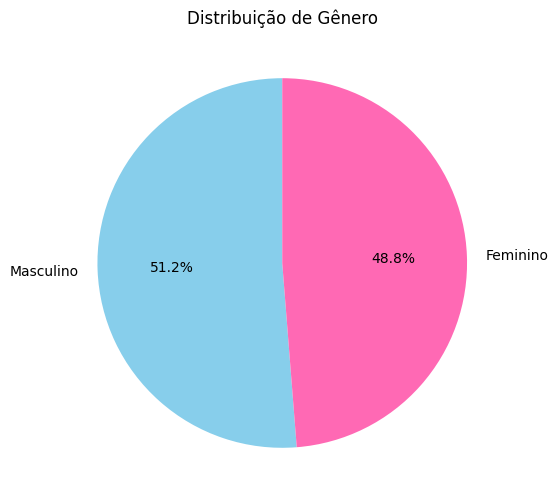

In [ ]:
Gênero = mh["Gênero"].value_counts()

cores = ["#87CEEB", "#FF69B4"]  # Azul céu, Rosa

# Gráfico de pizza
plt.figure(figsize=(8, 6))
plt.pie(
    Gênero,
    labels=Gênero.index,
    autopct='%1.1f%%', #Porcentagem dentro do grafico
    startangle=90,
    colors=cores
)

plt.title("Distribuição de Gênero")

plt.show()



#Nessa célula, inicialmente realizamos a contagem da quantidade de participantes em cada categoria da variável Gênero
#armazenando o resultado na variável Gênero. Em seguida, definimos uma paleta de cores para representar visualmente cada grupo e construímos um gráfico de pizza
#com o objetivo de ilustrar a proporção de estudantes do sexo masculino e feminino presentes na base de dados.
#Além disso, utilizamos o parâmetro autopct para exibir a porcentagem correspondente a cada categoria diretamente no gráfico,
#facilitando a interpretação dos resultados. Essa visualização permite compreender rapidamente a composição da amostra e verificar
#se há equilíbrio entre os grupos analisados.

## Contagem de cada idade

In [ ]:
mh["Idade"].value_counts().sort_index()

#Nessa célula, contabilizamos a quantidade de estudantes em cada idade presente na base de dados. O método value_counts() foi utilizado para calcular
#a frequência de ocorrência de cada idade, enquanto sort_index() organizou os resultados em ordem crescente.
#Essa análise contribui para a caracterização do perfil dos participantes e fornece uma visão geral da distribuição das idades na amostra estudada.

,count
Idade,
13,200
14,153
15,180
16,163
17,170
18,172
19,162


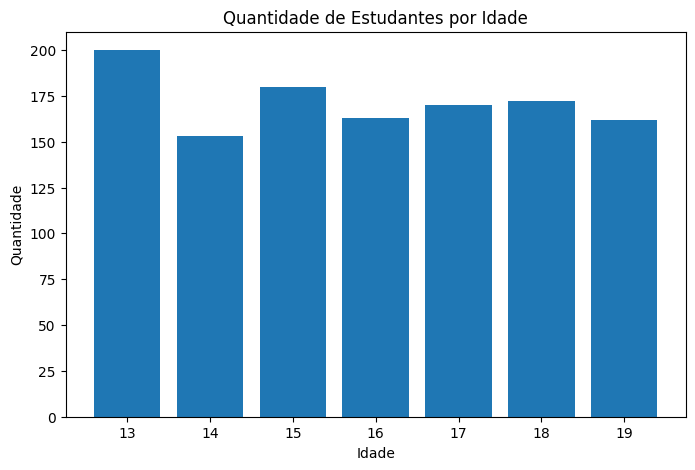

In [ ]:
idades = mh["Idade"].value_counts().sort_index()

plt.figure(figsize=(8, 5))
plt.bar(idades.index, idades.values)

plt.title("Quantidade de Estudantes por Idade")
plt.xlabel("Idade")
plt.ylabel("Quantidade")

plt.show()


#Nessa célula, construímos um gráfico de barras para representar a quantidade de estudantes em cada faixa etária presente na base de dados.
#Inicialmente, utilizamos os métodos value_counts() e sort_index() para calcular a frequência de cada idade e organizar os resultados em ordem crescente.
#Em seguida, empregamos a função plt.bar() para criar a visualização em barras, permitindo comparar de forma clara a distribuição dos participantes por idade.
#Essa análise auxilia na compreensão do perfil etário da amostra e na identificação de possíveis concentrações ou diferenças na representatividade das idades estudadas.

##Plataforma mais usada

In [ ]:

mh["Plataforma_usada"].value_counts()
#Nessa célula, utilizamos o comando value_counts() para contabilizar quantos estudantes utilizam cada uma das plataformas presentes na variável Plataforma_usada.
#Essa análise permitiu identificar quais redes sociais possuem maior adesão entre os participantes,
#auxiliando na compreensão dos hábitos de consumo digital da amostra estudada.

,count
Plataforma_usada,
Instagram,411
TikTok,398
Ambas,391


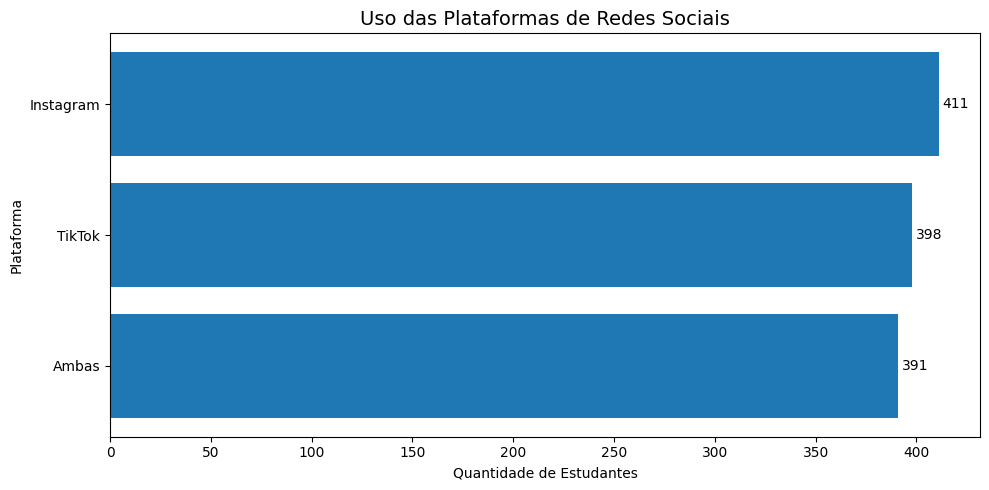

In [ ]:
plataformas = mh["Plataforma_usada"].value_counts()

plt.figure(figsize=(10, 5))
plt.barh(plataformas.index, plataformas.values)

plt.title("Uso das Plataformas de Redes Sociais", fontsize=14)
plt.xlabel("Quantidade de Estudantes")
plt.ylabel("Plataforma")

plt.gca().invert_yaxis()

for i, valor in enumerate(plataformas.values):
    plt.text(valor + 2, i, str(valor), va='center')

plt.tight_layout()
plt.show()

#Aqui, elaboramos um gráfico de barras horizontais para visualizar a frequência de uso das diferentes plataformas de redes sociais.
#Inicialmente, utilizamos o método value_counts() para contabilizar a quantidade de usuários em cada plataforma.
#Em seguida, aplicamos a função plt.barh() para representar essas informações graficamente, facilitando a comparação entre as categorias.
#Além disso, adicionamos rótulos com os valores absolutos em cada barra, tornando a interpretação dos resultados mais clara e objetiva.
#Essa análise possibilita identificar quais plataformas são mais utilizadas pelos participantes e compreender melhor seus hábitos digitais.

##Tempo médio gasto em redes sociais

In [ ]:

print(f"Média de horas por dia: {mh['Tempo_gasto_redes'].mean():.2f} horas")

#Nessa célula, calculamos o tempo médio diário que os estudantes dedicam às redes sociais.
#Para isso, utilizamos o método mean(), responsável por obter a média aritmética dos valores presentes na coluna.
#Em seguida, empregamos uma f-string para exibir o resultado de forma organizada e com duas casas decimais.
#Essa análise permite identificar, de maneira geral, quanto tempo os participantes permanecem conectados às redes sociais ao longo do dia,
#fornecendo um importante indicador para as investigações sobre os hábitos digitais e sua possível relação com aspectos da saúde mental.

Média de horas por dia: 4.54 horas


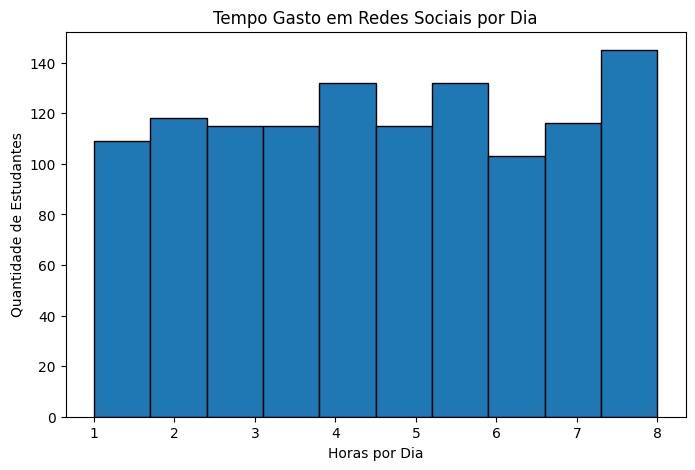

In [ ]:
plt.figure(figsize=(8, 5))
plt.hist(mh["Tempo_gasto_redes"], bins=10,  edgecolor="black")

plt.title("Tempo Gasto em Redes Sociais por Dia")
plt.xlabel("Horas por Dia")
plt.ylabel("Quantidade de Estudantes")

plt.show()

#Nessa célula, construímos um histograma para analisar a distribuição do tempo diário gasto pelos estudantes nas redes sociais.
#Utilizamos a variável Tempo_gasto_redes para representar a quantidade de horas dedicadas a essas plataformas, dividimos os dados em 10 intervalos (bins)
#para facilitar a visualização da frequência de ocorrência dos valores e usamos o edgecolor para limitar as barras e ficar visualmente melhor.
#Essa representação gráfica permite identificar padrões de comportamento, como as faixas de tempo mais comuns entre os participantes,
#além de possibilitar a observação da dispersão e concentração dos dados.

#Testando hipóteses

##Quanto mais tempo gasto em redes, menos sono?

In [ ]:

mh[["Tempo_gasto_redes", "Horas_dormidas"]].corr()

#Nessa célula, analisamos a correlação entre o tempo gasto nas redes sociais e a quantidade de horas dormidas
#pelos estudantes. Para isso, selecionamos essas duas variáveis e utilizamos o método corr(), responsável por calcular o coeficiente de correlação de Pearson.
#O objetivo dessa análise foi investigar se existe alguma relação linear
#entre o uso das redes sociais e a duração do sono dos participantes, verificando, por exemplo, se maiores tempos de uso estão associados a menos horas de descanso.

,Tempo_gasto_redes,Horas_dormidas
Tempo_gasto_redes,1.000000,-0.009472
Horas_dormidas,-0.009472,1.000000


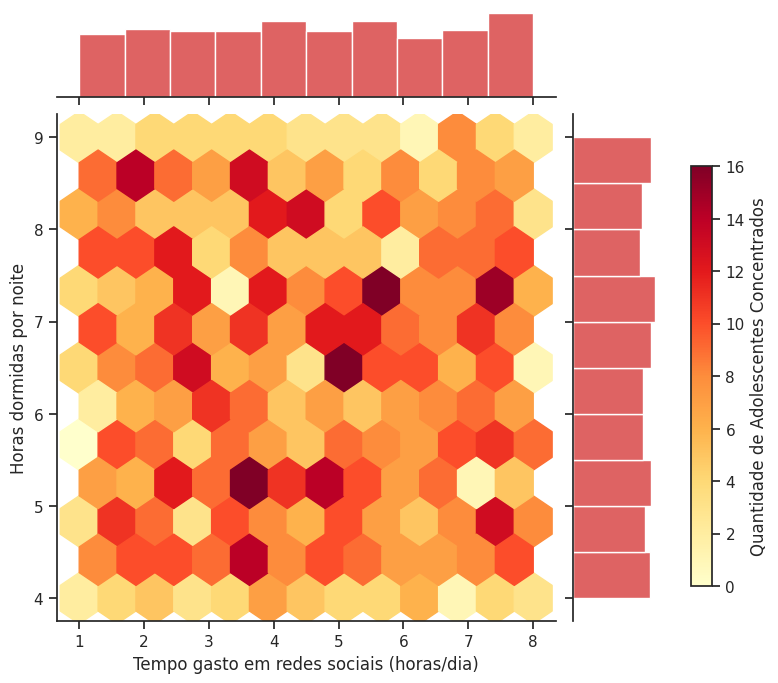

In [13]:
# Score para colorir os pontos

# Configurando o estilo do Seaborn para gráficos mais limpos
sns.set_theme(style="ticks")

# Criando um Jointplot Hexagonal para mostrar densidade de dados
g = sns.jointplot(
    data=mh,
    x="Tempo_gasto_redes",
    y="Horas_dormidas",
    kind="hex",
    cmap="YlOrRd",  # Transição de Amarelo (pouca gente) para Vermelho Escuro (muita gente)
    gridsize=12,    # Tamanho dos hexágonos
    height=7,
    marginal_kws=dict(bins=10, fill=True, color="#d32f2f") # Estilo dos histogramas das bordas
)

# Ajustando títulos e rótulos legíveis
# g.fig.suptitle("Densidade da Relação: Tempo em Redes Sociais vs Horas de Sono", fontsize=14, fontweight='bold', y=1.02)
g.set_axis_labels("Tempo gasto em redes sociais (horas/dia)", "Horas dormidas por noite", fontsize=12)

# Adicionando uma barra de cor (Colorbar) para indicar a quantidade de adolescentes
cbar_ax = g.fig.add_axes([1.02, 0.15, 0.03, 0.6])  # Posição da barra [esquerda, baixo, largura, altura]
plt.colorbar(g.ax_joint.collections[0], cax=cbar_ax, label="Quantidade de Adolescentes Concentrados")

plt.show()

#Nessa célula, construímos um gráfico de dispersão (scatter plot) para investigar a relação entre o tempo gasto nas redes sociais e
#a quantidade de horas dormidas pelos estudantes. Cada ponto do gráfico representa um participante da pesquisa,
#sendo que o eixo horizontal corresponde ao tempo diário de uso das redes sociais e o eixo vertical representa as horas de sono.
#Além disso, criamos um indicador denominado score, obtido pela diferença entre o tempo gasto nas redes sociais e as horas dormidas,
#que foi utilizado para colorir os pontos do gráfico. Dessa forma, a visualização permite identificar possíveis padrões,
#como a tendência de estudantes que utilizam mais as redes sociais apresentarem menos horas de sono.

##Quanto maior o nível de dependência, maior a ansiedade?

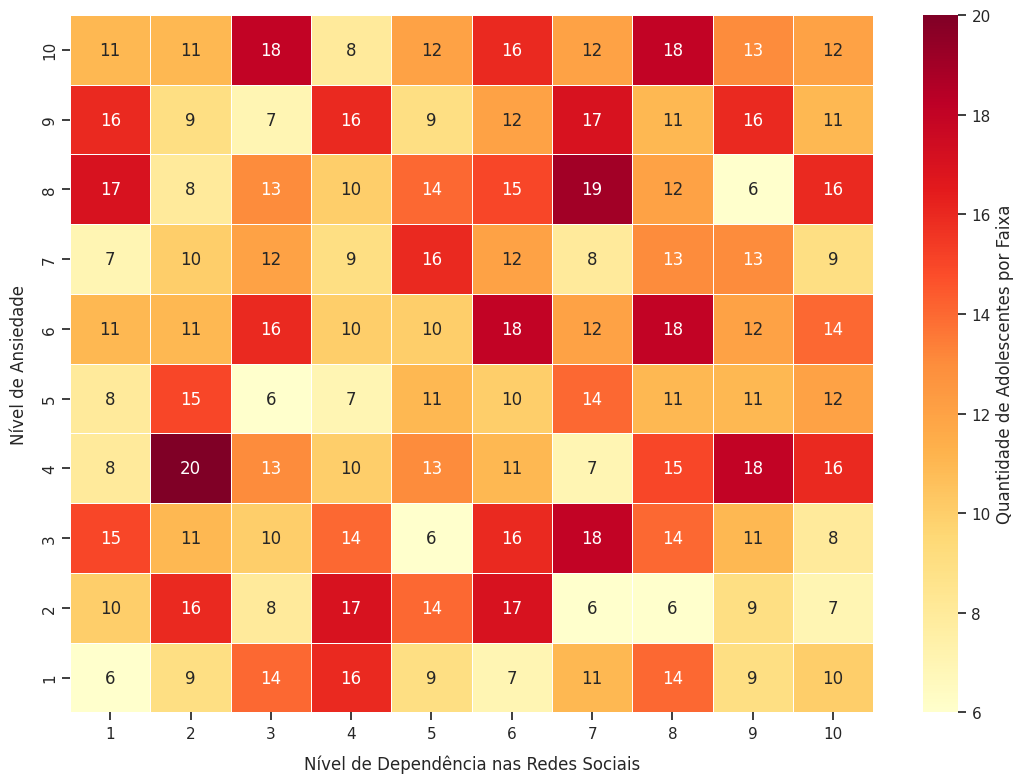

In [16]:
# 1. Definindo as variáveis e o cálculo original de score

# 1. Definindo os intervalos exatos dos eixos baseados na escala (Ex: 1 a 10)
# Criamos uma matriz de contagem para alimentar o heatmap tradicional
matriz_contagem = pd.crosstab(
    mh["Nivel_ansiedade"],
    mh["Nivel_dependência"]
).sort_index(ascending=False) # Inverte o eixo Y para o nível 10 ficar no topo

plt.figure(figsize=(11, 8))

# 2. Criando o Mapa de Calor (Heatmap)
ax = sns.heatmap(
    matriz_contagem,
    annot=True,               # Coloca o número exato de alunos dentro de cada quadrado
    fmt="d",                  # Garante que os números apareçam como inteiros
    cmap="YlOrRd",            # Degradê de Amarelo (pouco risco/gente) para Vermelho Escuro (crítico)
    linewidths=0.5,           # Linha fina branca separando os blocos
    cbar_kws={'label': 'Quantidade de Adolescentes por Faixa'}
)

# 3. Ajustando títulos e legendas explicativas
# plt.title("Matriz de Densidade: Nível de Dependência vs Nível de Ansiedade", fontsize=14, fontweight='bold', pad=20)
plt.xlabel("Nível de Dependência nas Redes Sociais", fontsize=12, labelpad=10)
plt.ylabel("Nível de Ansiedade", fontsize=12, labelpad=10)

plt.tight_layout()
plt.show()



#Nesta célula, utilizamos um gráfico de dispersão (scatter plot) para analisar a relação entre
#o nível de dependência das redes sociais e o nível de ansiedade dos participantes.
#Cada ponto representa um indivíduo da amostra, permitindo visualizar como essas duas variáveis
#se comportam em conjunto.
#Além disso, foi calculado um índice de risco médio a partir dos níveis de dependência e ansiedade,
#utilizado para colorir os pontos no gráfico. A escala de cores varia de baixo para alto risco,
#facilitando a identificação de participantes com maiores níveis simultâneos dessas características.
#Por meio dessa análise, é possível observar possíveis correlações entre dependência e ansiedade,
#bem como identificar padrões, concentrações e casos de maior vulnerabilidade dentro do conjunto de dados.

##Quem dorme mais tem menos ansiedade?

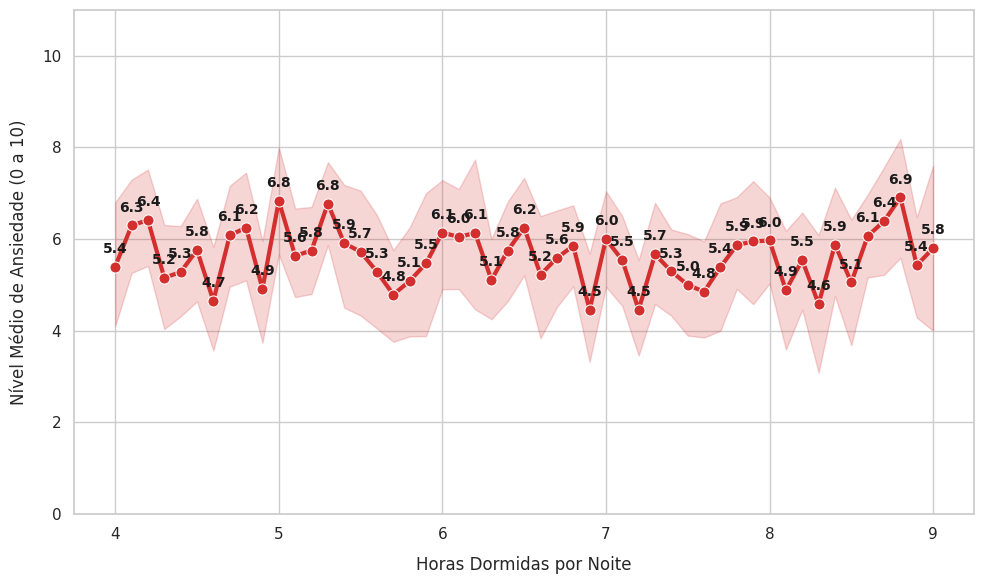

In [19]:
# Configurando um estilo limpo e de alta legibilidade
sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 6))

# Criando o gráfico de linha de médias
# O Seaborn calcula automaticamente a média de ansiedade para cada grupo de horas de sono
ax = sns.lineplot(
    data=mh,
    x="Horas_dormidas",
    y="Nivel_ansiedade",
    color="#d32f2f",      # Linha vermelha de alerta para destacar a tendência
    linewidth=3,
    marker="o",           # Adiciona uma bolinha em cada hora cheia para destacar o ponto exato
    markersize=8,
    errorbar=("ci", 95)   # Sombra sutil que mostra a variação estatística dos dados
)

# Adicionando os rótulos de dados (escrevendo o valor médio exato acima de cada marcador)
# Isso remove qualquer falta de informação do gráfico
for x_val, y_val in zip(mh.groupby("Horas_dormidas")["Nivel_ansiedade"].mean().index,
                        mh.groupby("Horas_dormidas")["Nivel_ansiedade"].mean().values):
    ax.annotate(f"{y_val:.1f}",
                (x_val, y_val),
                textcoords="offset points",
                xytext=(0, 10),
                ha='center',
                fontsize=10,
                fontweight='bold',
                color='#1a1a1a')

# Títulos e eixos claros e informativos
# plt.title("Tendência Média do Nível de Ansiedade por Horas de Sono", fontsize=14, fontweight='bold', pad=20)
plt.xlabel("Horas Dormidas por Noite", fontsize=12, labelpad=10)
plt.ylabel("Nível Médio de Ansiedade (0 a 10)", fontsize=12, labelpad=10)

# Ajustando os limites para os rótulos não serem cortados
plt.ylim(0, 11)
plt.xticks(range(int(mh["Horas_dormidas"].min()), int(mh["Horas_dormidas"].max()) + 1))

plt.tight_layout()
plt.show()


#Nesta célula, utilizamos um gráfico de dispersão (scatter plot) para analisar a relação entre
#a quantidade de horas dormidas e o nível de ansiedade dos participantes.
#Cada ponto representa um indivíduo da amostra, permitindo observar como os níveis de ansiedade
#se distribuem em função do tempo de sono.
#A coloração dos pontos foi definida pelo próprio nível de ansiedade, utilizando uma escala de cores
#que varia de menor para maior intensidade, facilitando a identificação de participantes com níveis
#mais elevados dessa condição.
#Por meio dessa visualização, é possível investigar a existência de padrões ou tendências entre
#as horas de sono e a ansiedade, verificando, por exemplo, se menores períodos de descanso estão
#associados a níveis mais altos de ansiedade entre os adolescentes analisados.

##Nível de vício varia por gênero?

In [ ]:

mh.groupby("Gênero")["Nivel_dependência"].mean()

#Nessa célula, analisamos se o nível médio de dependência das redes sociais varia entre os gêneros.
#Para isso, utilizamos o método groupby() para agrupar os participantes de acordo com a variável Gênero e, em seguida, aplicamos a função mean()
#sobre a variável Nivel_dependência. Essa análise permitiu comparar a média dos níveis de dependência entre os grupos,
#possibilitando identificar se existe alguma diferença significativa no comportamento relacionado ao uso das redes sociais entre estudantes do sexo masculino e feminino.

,Nivel_dependência
Gênero,
Feminino,5.48547
Masculino,5.64065


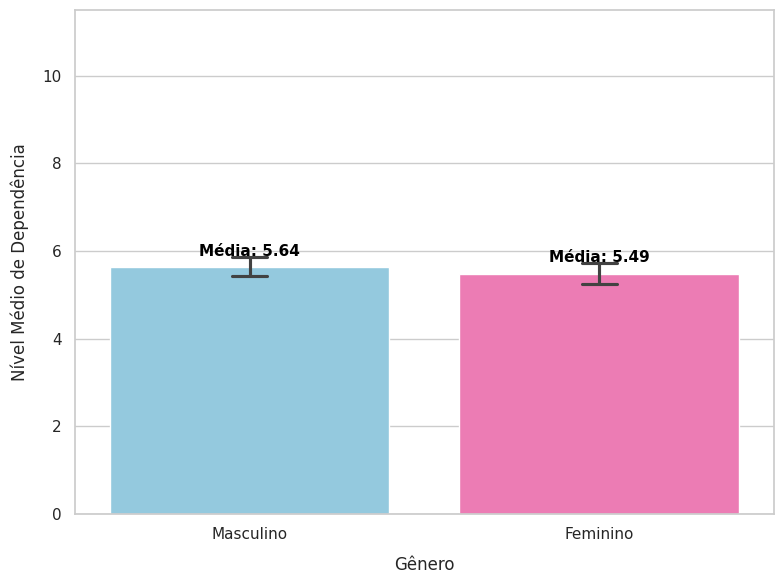

In [21]:
# Configurando um estilo limpo e profissional
sns.set_theme(style="whitegrid")
plt.figure(figsize=(8, 6))

# Criando o gráfico de barras que calcula a MÉDIA automaticamente
ax = sns.barplot(
    data=mh,
    x="Gênero",
    y="Nivel_dependência",
    hue="Gênero",
    palette={
        "Masculino": "#87CEEB",
        "Feminino": "#FF69B4"
    },
    errorbar=("ci", 95),  # Adiciona a barra de erro estatístico no topo
    capsize=0.1,          # Adiciona uma "aba" na barra de erro para ficar mais visível
    legend=False
)

# Adicionando os rótulos de dados (valores exatos da média em cima de cada barra)
for p in ax.patches:
    height = p.get_height()
    if height > 0:
        ax.annotate(f'Média: {height:.2f}',
                    (p.get_x() + p.get_width() / 2., height),
                    ha='center', va='baseline',
                    fontsize=11, color='black', fontweight='bold',
                    xytext=(0, 8), textcoords='offset points')

# Títulos e eixos claros e informativos
# plt.title("Comparação do Nível Médio de Dependência por Gênero", fontsize=14, fontweight='bold', pad=20)
plt.xlabel("Gênero", fontsize=12, labelpad=10)
plt.ylabel("Nível Médio de Dependência", fontsize=12, labelpad=10)

# Ajustando o limite do eixo Y para os rótulos não sumirem
plt.ylim(0, mh["Nivel_dependência"].max() + 1.5)

plt.tight_layout()
plt.show()

#Nessa célula, utilizamos um gráfico do tipo violin plot para analisar a distribuição dos níveis de dependência em relação às redes sociais
#de acordo com o gênero dos participantes. Diferentemente de um gráfico de barras, essa visualização permite observar não apenas
#a tendência central dos dados, mas também a dispersão e a concentração dos valores em cada grupo.
#As cores foram definidas para facilitar a distinção entre os gêneros, tornando a interpretação dos resultados mais intuitiva.
#Por meio dessa análise, foi possível investigar se existem diferenças no comportamento relacionado à dependência das redes sociais
#entre estudantes do sexo masculino e feminino.

##Estresse varia com interação Social?

In [ ]:

mh.groupby("Nível_interação_social")["Nivel_estress"].mean().round(2)

#Nessa célula, investigamos como os níveis de estresse dos estudantes variam de acordo com o grau de interação social relatado pelos participantes.
#Para isso, utilizamos o método groupby() para agrupar os dados com base na variável Nível_interação_social e, em seguida, calculamos a média
#da variável Nivel_estress por meio da função mean(). Por fim, aplicamos o método round(2) para arredondar os resultados para duas casas decimais,
#facilitando a leitura e a interpretação dos valores.
#Essa análise permite identificar se estudantes com diferentes níveis de interação social apresentam diferenças nos níveis médios de estresse.

,Nivel_estress
Nível_interação_social,
Alto,5.51
Baixo,5.35
Médio,5.48


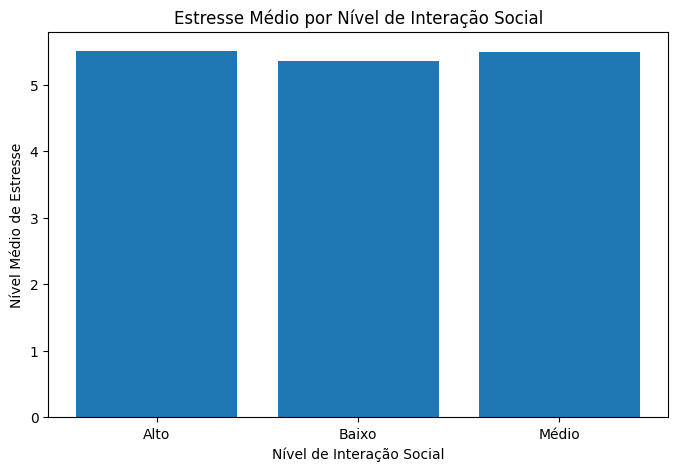

In [ ]:
estresse = mh.groupby("Nível_interação_social")["Nivel_estress"].mean()

plt.figure(figsize=(8, 5))
plt.bar(estresse.index, estresse.values)

plt.title("Estresse Médio por Nível de Interação Social")
plt.xlabel("Nível de Interação Social")
plt.ylabel("Nível Médio de Estresse")

plt.show()

#Nessa célula, construímos um gráfico de barras para visualizar como o nível médio de estresse varia de acordo com o nível de interação social dos estudantes.
#Inicialmente, agrupamos os participantes com base na variável Nível_interação_social e calculamos a média dos valores da variável Nivel_estress para cada grupo.
#Em seguida, utilizamos essas informações para gerar uma representação gráfica que facilita a comparação entre os diferentes níveis de interação social.
#Essa análise permite investigar se estudantes com menor ou maior interação social apresentam diferenças nos níveis médios de estresse, contribuindo
#para a compreensão dos fatores associados ao bem-estar emocional dos participantes.

##Mais atividade fisica = melhor nota?

In [ ]:

correlacao = mh["Atividade_fisica"].corr(mh["Performance_academica"])

print(f"Correlação: {correlacao:.3f}")

#Correlação positiva → mais atividade física tende a estar associada a melhores notas.
#Correlação próxima de zero → pouca ou nenhuma relação.
#Correlação negativa → mais atividade física tende a estar associada a notas menores.

#Nessa célula, investigamos a existência de uma possível relação entre a prática de atividade física e o desempenho acadêmico dos estudantes.
#Para isso, calculamos o coeficiente de correlação de Pearson entre as variáveis Atividade_fisica e Performance_academica, utilizando o método corr().
#Essa análise teve como objetivo verificar se estudantes que realizam mais atividades físicas tendem a apresentar melhor desempenho acadêmico.




Correlação: 0.023


/tmp/ipykernel_2593/505846139.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


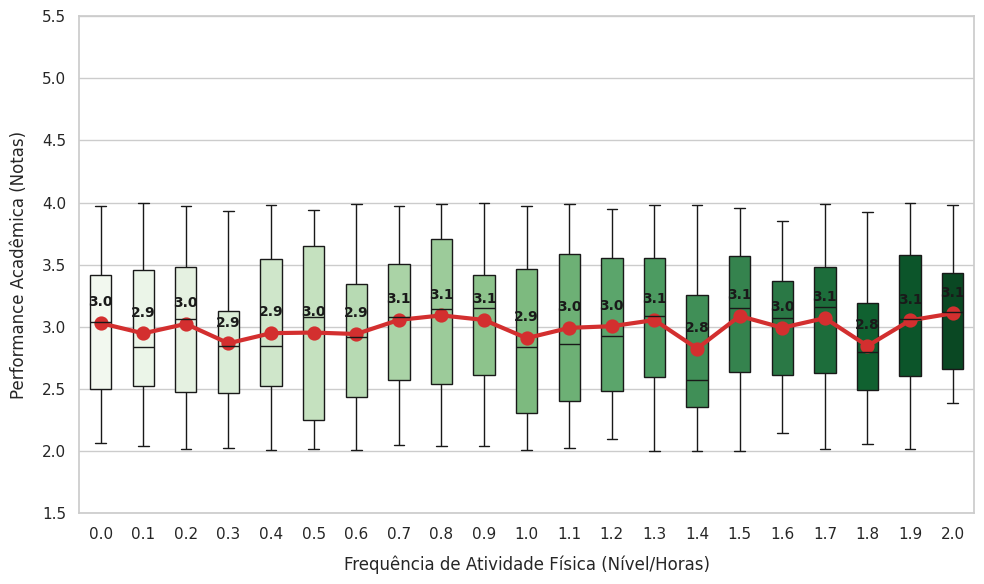

In [23]:
# Ajustando para um estilo limpo e de alta legibilidade
sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 6))

# 1. Criando o Boxplot de fundo com cores suaves
# Ele mostra onde estão a maioria das notas (caixa), os valores máximos e mínimos
sns.boxplot(
    data=mh,
    x="Atividade_fisica",
    y="Performance_academica",
    palette="Greens",        # Tons de verde combinando com a ideia de saúde/esporte
    width=0.5,
    fliersize=4              # Tamanho dos pontos fora da curva (outliers)
)

# 2. Calculando as médias de notas para cada nível de atividade física e plotando a linha guia
# O pointplot calcula a média automaticamente e une os pontos com uma linha destacada
sns.pointplot(
    data=mh,
    x="Atividade_fisica",
    y="Performance_academica",
    color="#d32f2f",          # Vermelho escuro para a linha de tendência central se destacar
    linewidth=3,
    errorbar=None,            # Remove as barras de erro pequenas para o visual ficar limpo
    markers="o",
    markersize=8
)

# 3. Adicionando os valores exatos da média em cima de cada ponto da linha
valores_medios = mh.groupby("Atividade_fisica")["Performance_academica"].mean()
for i, media in enumerate(valores_medios):
    plt.annotate(
        f"{media:.1f}",
        (i, media),
        textcoords="offset points",
        xytext=(0, 12),
        ha='center',
        fontsize=10,
        fontweight='bold',
        color='#1a1a1a'
    )

# 4. Títulos e eixos informativos
# plt.title("Impacto da Atividade Física na Performance Acadêmica", fontsize=14, fontweight='bold', pad=20)
plt.xlabel("Frequência de Atividade Física (Nível/Horas)", fontsize=12, labelpad=10)
plt.ylabel("Performance Acadêmica (Notas)", fontsize=12, labelpad=10)

# Ajustando os limites para os rótulos de dados não sumirem no topo
plt.ylim(mh["Performance_academica"].min() - 0.5, mh["Performance_academica"].max() + 1.5)

plt.tight_layout()
plt.show()
#Nessa célula, construímos um gráfico de dispersão para investigar visualmente a relação entre a prática de atividade física e a
#performance acadêmica dos estudantes. Cada ponto do gráfico representa um participante da pesquisa, sendo posicionado de acordo com seu nível de atividade física
#e seu desempenho acadêmico. Além disso, aplicamos uma escala de cores baseada na variável Performance_academica, permitindo identificar visualmente estudantes
#com melhores ou piores resultados. Para complementar a análise, adicionamos uma linha de tendência linear, com o objetivo de evidenciar a direção geral
#da relação entre as variáveis. Essa abordagem possibilita avaliar se maiores níveis de atividade física estão associados a um melhor desempenho acadêmico.

##Como se distribuem os níveis de ansiedade e estresse?

In [ ]:

mh[["Nivel_ansiedade", "Nivel_estress"]].describe()

#Nessa célula, realizamos uma análise descritiva das variáveis Nivel_ansiedade e Nivel_estress por meio do método describe().
#O objetivo foi obter um resumo estatístico dessas duas dimensões relacionadas à saúde mental dos estudantes,
#permitindo compreender como seus valores estão distribuídos na amostra.
#Essa etapa fornece informações importantes sobre a tendência central e a dispersão dos dados, contribuindo para uma interpretação
#mais detalhada dos níveis de ansiedade e estresse apresentados pelos participantes.

,Nivel_ansiedade,Nivel_estress
count,1200.000000,1200.000000
mean,5.636667,5.445833
std,2.859453,2.903290
min,1.000000,1.000000
25%,3.000000,3.000000
50%,6.000000,5.000000
75%,8.000000,8.000000
max,10.000000,10.000000


##Quanto mais ansiedade, mais estresse?

In [ ]:

mh["Nivel_ansiedade"].corr(mh["Nivel_estress"])

#Nessa célula, analisamos a relação entre os níveis de ansiedade e estresse dos estudantes por meio do cálculo do coeficiente de correlação de Pearson.
#Para isso, utilizamos o método corr() para verificar a intensidade e a direção da associação linear entre as variáveis Nivel_ansiedade e Nivel_estress.
#Além disso, estabelecemos uma tabela de classificação para interpretar a força da correlação obtida.
#Essa análise teve como objetivo investigar se estudantes com níveis mais elevados de ansiedade também tendem a apresentar maiores níveis de estresse.


#Correlação       Significado

#0,00 a 0,19     Muito fraca
#0,20 a 0,39       Fraca
#0,40 a 0,59      Moderada
#0,60 a 0,79       Forte
#0,80 a 1,00    Muito forte

np.float64(0.01581125345622227)

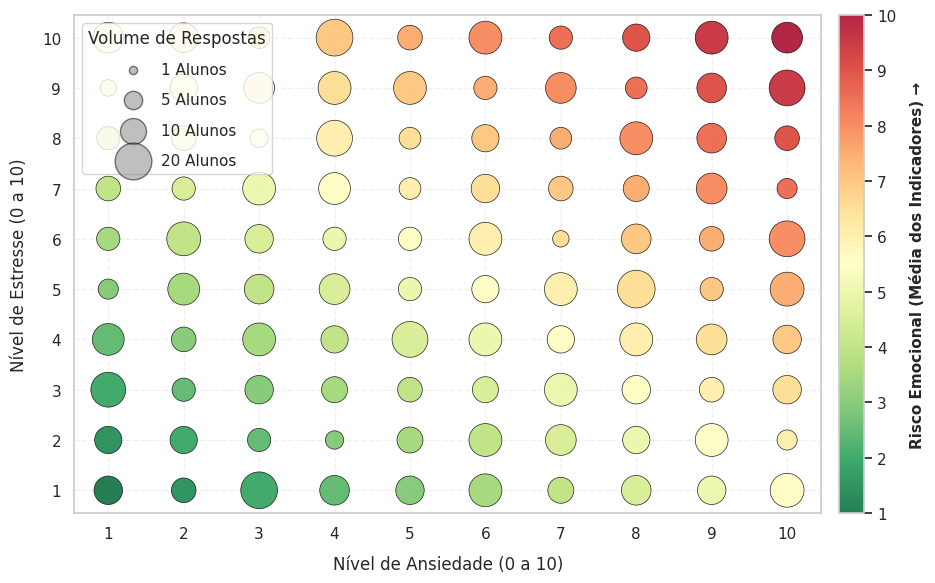

In [25]:
# 1. Definindo as variáveis e o cálculo original de score de risco emocional
mh["Score_Risco_Emocional"] = (mh["Nivel_ansiedade"] + mh["Nivel_estress"]) / 2

# 2. Agrupando os dados idênticos para contar a frequência de alunos em cada coordenada (X, Y)
contagem_pontos = mh.groupby(['Nivel_ansiedade', 'Nivel_estress', 'Score_Risco_Emocional']).size().reset_index(name='Quantidade')

plt.figure(figsize=(10, 6))

# 3. Criando o gráfico de dispersão com tamanho baseado no volume de alunos
scatter = plt.scatter(
    x=contagem_pontos["Nivel_ansiedade"],
    y=contagem_pontos["Nivel_estress"],
    s=contagem_pontos["Quantidade"] * 35,          # Define o tamanho dos círculos conforme a quantidade de respostas
    c=contagem_pontos["Score_Risco_Emocional"],    # Mantém o seu degradê original pelo score calculado
    cmap="RdYlGn_r",                               # Verde -> Amarelo -> Vermelho (Invertido)
    alpha=0.85,
    edgecolors="black",                            # Linha preta sutil ao redor para destacar esferas sobrepostas
    linewidths=0.5
)

# 4. Adicionando a barra de cores (Colorbar) explicativa
cbar = plt.colorbar(scatter, pad=0.02)
cbar.set_label("Risco Emocional (Média dos Indicadores) →", fontsize=11, fontweight='bold', labelpad=10)

# 5. Criando uma legenda dinâmica para o tamanho das esferas (Frequência Absoluta)
valores_legenda = [1, 5, 10, 20] # Valores padrão demonstrativos para a escala do tamanho
for qte in valores_legenda:
    plt.scatter([], [], c='gray', alpha=0.5, s=qte * 35, label=f'{qte} Alunos', edgecolors='black')
plt.legend(title="Volume de Respostas", loc="upper left", scatterpoints=1, labelspacing=1, frameon=True)

# 6. Títulos, rótulos e eixos informativos completos
# plt.title("Mapeamento de Risco: Nível de Ansiedade vs Nível de Estresse", fontsize=14, fontweight='bold', pad=20)
plt.xlabel("Nível de Ansiedade (0 a 10)", fontsize=12, labelpad=10)
plt.ylabel("Nível de Estresse (0 a 10)", fontsize=12, labelpad=10)

# Fixando intervalos exatos de 1 em 1 nos eixos para corresponder à escala do dataset
plt.xticks(range(int(mh["Nivel_ansiedade"].min()), int(mh["Nivel_ansiedade"].max()) + 1))
plt.yticks(range(int(mh["Nivel_estress"].min()), int(mh["Nivel_estress"].max()) + 1))

plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

#Nessa célula, analisamos a relação entre os níveis de ansiedade e estresse dos estudantes por meio do cálculo do coeficiente de correlação de Pearson.
#Para isso, utilizamos o método corr() para verificar a intensidade e a direção da associação linear entre as variáveis Nivel_ansiedade e Nivel_estress.
#Além disso, estabelecemos uma tabela de classificação para auxiliar na interpretação da força da correlação obtida.
#Essa análise teve como objetivo investigar se estudantes com níveis mais elevados de ansiedade também tendem a apresentar maiores níveis de estresse,
#contribuindo para a compreensão da interação entre esses dois importantes indicadores de saúde mental.

##Depressão, tem vinculo com o consumo de mais tela antes de dormir?

In [ ]:

mh.groupby("Depressão")["Tempo_tela_antes_dormir"].mean().round(2)

#Nessa célula, investigamos se existe alguma associação entre os níveis de depressão dos estudantes e o tempo de exposição às telas antes de dormir.
#Para isso, utilizamos o método groupby() para agrupar os participantes de acordo com a variável Depressão e, em seguida, calculamos
#a média do tempo de tela antes de dormir para cada grupo. Por fim, aplicamos o método round(2)
#para arredondar os resultados para duas casas decimais, facilitando a interpretação dos dados. Essa análise teve como objetivo
#verificar se estudantes com diferentes níveis de depressão apresentam padrões distintos de uso de dispositivos eletrônicos no período que antecede o sono.

,Tempo_tela_antes_dormir
Depressão,
0,1.74
1,1.67


/tmp/ipykernel_2593/2620235268.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(


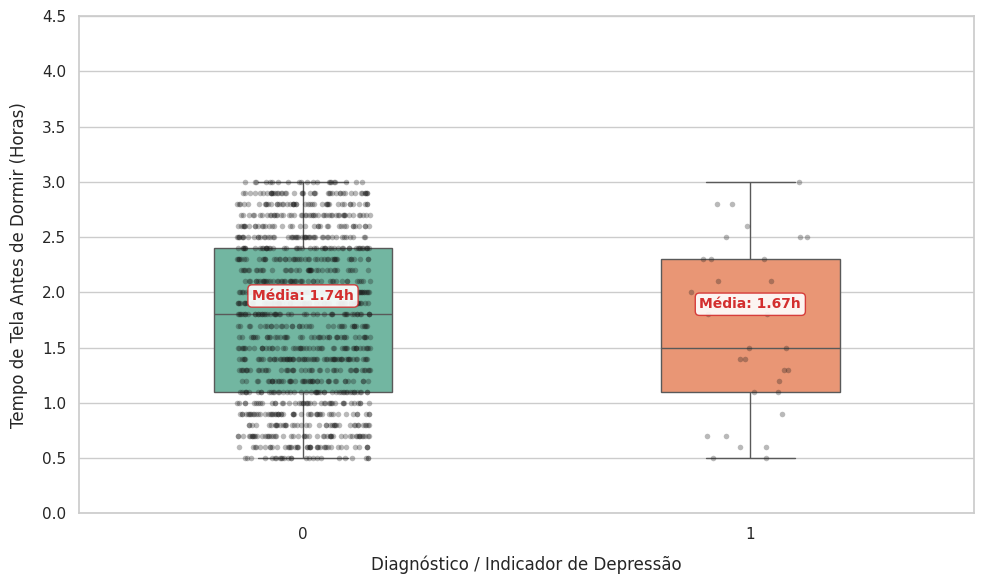

In [28]:
# Ajustando para um estilo limpo e de alta legibilidade
sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 6))

# 1. Criando o Boxplot moderno com o Seaborn
# Usamos uma paleta de cores sutil para servir de fundo
ax = sns.boxplot(
    data=mh,
    x="Depressão",
    y="Tempo_tela_antes_dormir",
    palette="Set2",
    width=0.4,
    fliersize=0  # Remove os pontos repetidos de outliers do boxplot puro, pois o stripplot vai desenhá-los
)

# 2. Adicionando os pontos reais (Stripplot) por cima para dar volume visual
# O jitter espalha os pontos para as laterais eliminando a sobreposição cega
sns.stripplot(
    data=mh,
    x="Depressão",
    y="Tempo_tela_antes_dormir",
    color="#1a1a1a",
    size=4,
    alpha=0.3,
    jitter=0.15
)

# 3. Calculando as médias e adicionando rótulos com os valores exatos
valores_medios = mh.groupby("Depressão")["Tempo_tela_antes_dormir"].mean()
for i, media in enumerate(valores_medios):
    plt.annotate(
        f"Média: {media:.2f}h",
        (i, media),
        textcoords="offset points",
        xytext=(0, 15),
        ha='center',
        fontsize=10,
        fontweight='bold',
        color='#d32f2f',
        bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="#d32f2f", lw=1, alpha=0.9)
    )

# 4. Títulos e rótulos informativos e bem destacados
# plt.title("Impacto do Tempo de Tela Antes de Dormir nos Indicadores de Depressão", fontsize=14, fontweight='bold', pad=20)
plt.xlabel("Diagnóstico / Indicador de Depressão", fontsize=12, labelpad=10)
plt.ylabel("Tempo de Tela Antes de Dormir (Horas)", fontsize=12, labelpad=10)

# Ajustando o limite superior para o balão da média não ser cortado
plt.ylim(mh["Tempo_tela_antes_dormir"].min() - 0.5, mh["Tempo_tela_antes_dormir"].max() + 1.5)

plt.tight_layout()
plt.show()

#Nessa célula, utilizamos um gráfico do tipo boxplot para analisar a distribuição do tempo de tela antes de dormir em função dos
#diferentes níveis de depressão dos estudantes. Essa visualização permite comparar não apenas os valores médios entre os grupos,
#mas também aspectos importantes da distribuição dos dados, como a mediana, a dispersão e a presença de possíveis valores atípicos (outliers).
#Dessa forma, foi possível investigar se estudantes com diferentes níveis de depressão apresentam padrões distintos de uso de
#dispositivos eletrônicos no período que antecede o sono.

##Qual plataforma está associada ao maior nível médio de dependência?

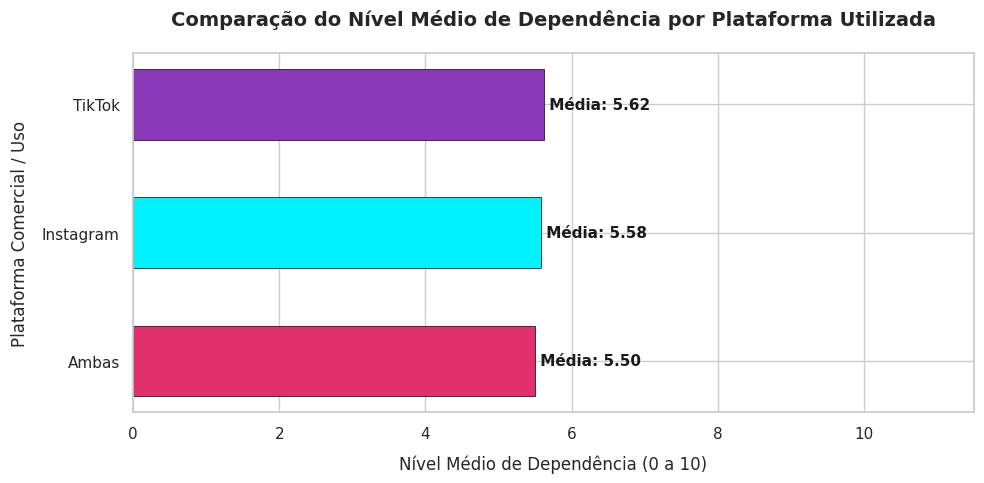

In [29]:
# 1. Calculando a média de dependência por plataforma (conforme seu código original)
dependencia = (
    mh.groupby("Plataforma_usada")["Nivel_dependência"]
    .mean()
    .sort_values()
)

# Configurando o estilo visual
sns.set_theme(style="whitegrid")
fig, ax = plt.subplots(figsize=(10, 5))

# 2. Criando o gráfico de barras horizontais com cores personalizadas para cada plataforma
cores_plataformas = ["#E1306C", "#00f2fe", "#8a3ab9"] # Cores que remetem ao Instagram, TikTok e Ambas
barras = ax.barh(
    dependencia.index,
    dependencia.values,
    color=cores_plataformas[:len(dependencia)], # Garante o mapeamento correto de cores
    height=0.55,                                # Ajusta a espessura das barras
    edgecolor="black",
    linewidth=0.5
)

# 3. Adicionando de forma automática a QUANTIDADE EXATA (Média) ao final de cada barra
ax.bar_label(
    barras,
    fmt=' Média: %.2f',              # Formata para exibir "Média: X.XX"
    fontsize=11,
    fontweight='bold',
    color='#1a1a1a'
)

# 4. Títulos e eixos informativos
plt.title("Comparação do Nível Médio de Dependência por Plataforma Utilizada", fontsize=14, fontweight='bold', pad=20)
plt.xlabel("Nível Médio de Dependência (0 a 10)", fontsize=12, labelpad=10)
plt.ylabel("Plataforma Comercial / Uso", fontsize=12, labelpad=10)

# Ajustando o limite do eixo X para que os textos das barras não fiquem cortados na lateral
plt.xlim(0, mh["Nivel_dependência"].max() + 1.5)

plt.tight_layout()
plt.show()


#Nesta célula, utilizamos um gráfico de barras horizontais para comparar o nível médio de
#dependência das redes sociais entre as diferentes plataformas utilizadas pelos participantes.
#Inicialmente, os dados foram agrupados por plataforma, calculando-se a média do nível de
#dependência para cada uma delas. Em seguida, os valores foram ordenados de forma crescente,
#facilitando a visualização e comparação dos resultados.
#Cada barra representa uma plataforma específica, enquanto seu comprimento indica o nível
#médio de dependência associado aos usuários daquela plataforma.
#Por meio dessa análise, é possível identificar quais plataformas apresentam maiores ou menores
#índices médios de dependência, contribuindo para a compreensão do impacto potencial de cada
#rede social no comportamento dos adolescentes estudados.

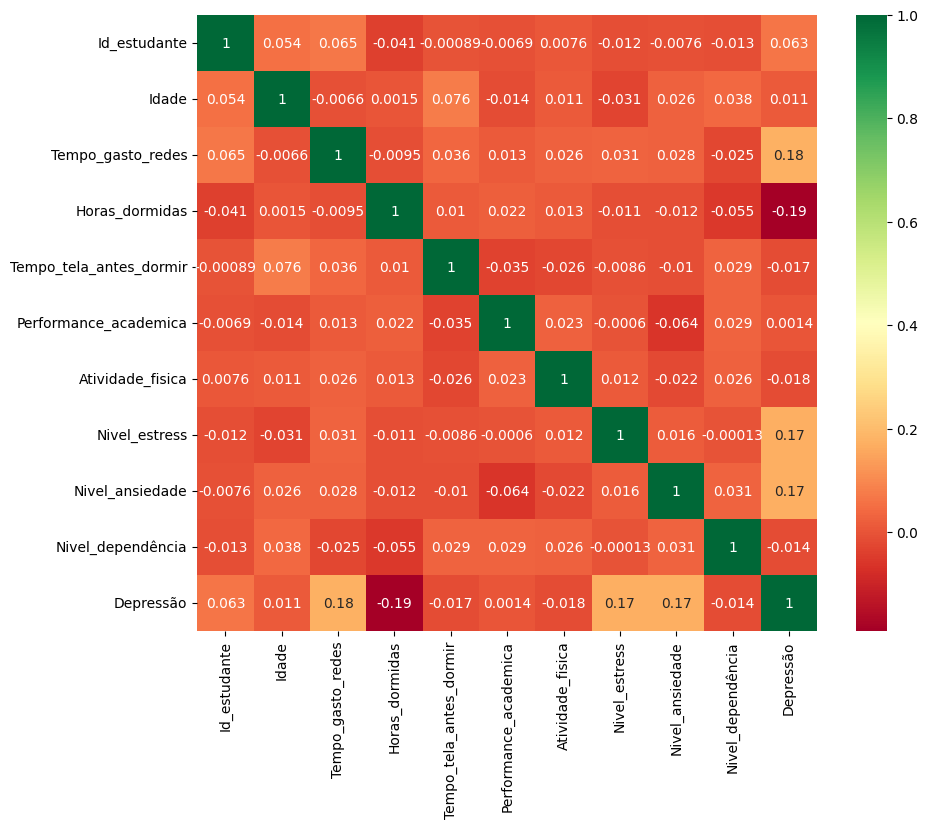

In [ ]:
plt.figure(figsize=(10,8))
sns.heatmap(
    mh.corr(numeric_only=True),
    annot=True,
    cmap="RdYlGn"
)
plt.show()

#Nessa célula, construímos um mapa de calor (heatmap) para visualizar as correlações existentes entre todas as variáveis numéricas da base de dados.
#Para isso, utilizamos o método corr() para calcular os coeficientes de correlação de Pearson e, em seguida, representamos esses valores graficamente com o
#auxílio da função heatmap() da biblioteca Seaborn. Essa visualização permite identificar padrões de associação entre as variáveis, destacando tanto correlações
#positivas quanto negativas, além de evidenciar quais relações apresentam maior ou menor intensidade. Dessa forma, o mapa de calor fornece uma visão geral das
#interações presentes no conjunto de dados, auxiliando na identificação de possíveis fatores relacionados à saúde mental e aos hábitos dos estudantes.